# Project Introduction

<b>Project Title:</b>

✈️ AirFly Insights

Data Visualization and Analysis of Airline Operations

<b>Project Objective</b>

The main objective of this project is to analyze airline flight operations data and identify patterns related to traffic, delays, and cancellations.

This project aims to:
1. Understand flight traffic distribution across airlines, routes, airports, and time.

2. Analyze different types of delays and their root causes.

3. Identify delay-prone routes and airports.

4. Study seasonal trends in cancellations.

5. Provide insights that can help improve airline scheduling and operational efficiency.

<b> US Flight Delays dataset obtained from Kaggle </b>
<br>
Dataset link - https://www.kaggle.com/datasets/usdot/flight-delays

<b>Dataset Overview</b>

The dataset contains detailed airline flight operation records including:

1. Airline information

2. Origin and destination airports

3. Departure and arrival times

4. Delay minutes by category

5. Cancellation information

6. Date and time details

<b>Key Features Used in Analysis:</b>

* AIRLINE

* ORIGIN_AIRPORT

* DESTINATION_AIRPORT

* ARRIVAL_DELAY

* AIRLINE_DELAY

* WEATHER_DELAY

* AIR_SYSTEM_DELAY

* LATE_AIRCRAFT_DELAY

* SECURITY_DELAY

* MONTH_NAME

* DAY_OF_WEEK

* DEPARTURE_HOUR

The dataset contains millions of flight records, making it suitable for identifying large-scale operational patterns and trends.

# Milestone 1: Data Foundation and Cleaning

In [1]:
import pandas as pd
df = pd.read_csv("flights.csv", low_memory=False, dtype={'ORIGIN_AIRPORT': str, 'DESTINATION_AIRPORT': str})
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


```
Dataset Highlights:
    Total Records: 5,819,079 flights
    Total Features Used: 31 columns
    Data includes flight scheduling, actual timing, delay causes, cancellation information, and airport route details.
```

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [3]:
print(df.isnull().sum())

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64


In [4]:
required_features = [
    # Time & Flight Info
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',

    # Route Info
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',

    # Time Columns
    'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
    'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',

    # Delay Columns
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY', 'WEATHER_DELAY',
    'AIRLINE_DELAY', 'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY',

    # Cancellation & Diversion
    'CANCELLED', 'CANCELLATION_REASON', 'DIVERTED',

    # Flight Duration
    'AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT'
]
flights = df[required_features]
print(flights.columns)
print(flights.shape)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'WEATHER_DELAY', 'AIRLINE_DELAY', 'SECURITY_DELAY',
       'LATE_AIRCRAFT_DELAY', 'CANCELLED', 'CANCELLATION_REASON', 'DIVERTED',
       'AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT'],
      dtype='object')
(5819079, 27)


<b> Column meanings: </b>
```
    YEAR  -->  Year in which flight operated
    MONTH  --> Month of flight (1–12)
    DAY  --> Day of the month
    DAY_OF_WEEK  --> Day number of week (1=Monday … 7=Sunday)
    DATE  --> Complete flight date created from YEAR, MONTH, DAY
    AIRLINE  --> Airline company code
    FLIGHT_NUMBER  --> Unique flight identification number
    ORIGIN_AIRPORT  --> Airport where flight started
    DESTINATION_AIRPORT  --> Airport where flight landed
    DISTANCE  --> Distance between airports (Miles)
    SCHEDULED_DEPARTURE  --> Planned departure time (HHMM format)
    DEPARTURE_TIME  --> Actual departure time
    SCHEDULED_ARRIVAL  --> Planned arrival time (HHMM format)
    ARRIVAL_TIME  --> Actual arrival time
    DEPARTURE_DELAY  --> Delay in departure time (Minutes)  (Positive Value → Flight delayed, Negative Value → Flight early)
    ARRIVAL_DELAY  --> Delay in arrival time (Minutes)
    AIR_SYSTEM_DELAY  --> Delay caused by air traffic control system
    WEATHER_DELAY  --> Delay caused by weather conditions
    AIRLINE_DELAY  --> Delay caused by airline operational issues (Crew,Maintenance delay)
    SECURITY_DELAY  --> Delay caused by airport security checks
    LATE_AIRCRAFT_DELAY  --> Delay due to late arrival of aircraft from
                                previous flight
    CANCELLED  --> Indicates whether flight was cancelled (1=Yes, 0=No)
    CANCELLATION_REASON  --> Reason for cancellation (A,B,C,D, Not Cancelled)
                                A → Airline issue  
                                B → Weather issue  
                                C → Air traffic issue  
                                D → Security issue  
                                Not Cancelled → Flight operated normally
    DIVERTED  --> Indicates whether flight was diverted (1=Yes, 0=No)
    AIR_TIME  --> Total time aircraft was in air (Minutes)
    ELAPSED_TIME --> Total journey time including taxi time
    TAXI_IN  --> Time from landing to reaching gate
    TAXI_OUT  --> Time from gate to take-off
```

In [5]:
print(flights.isnull().sum())

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
DISTANCE                     0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
DEPARTURE_DELAY          86153
ARRIVAL_DELAY           105071
AIR_SYSTEM_DELAY       4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
LATE_AIRCRAFT_DELAY    4755640
CANCELLED                    0
CANCELLATION_REASON    5729195
DIVERTED                     0
AIR_TIME                105071
ELAPSED_TIME            105071
TAXI_IN                  92513
TAXI_OUT                 89047
dtype: int64


In [6]:
print(flights[flights.isna().any(axis=1)])

         YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER ORIGIN_AIRPORT  \
0        2015      1    1            4      AS             98            ANC   
1        2015      1    1            4      AA           2336            LAX   
2        2015      1    1            4      US            840            SFO   
3        2015      1    1            4      AA            258            LAX   
4        2015      1    1            4      AS            135            SEA   
...       ...    ...  ...          ...     ...            ...            ...   
5819074  2015     12   31            4      B6            688            LAX   
5819075  2015     12   31            4      B6            745            JFK   
5819076  2015     12   31            4      B6           1503            JFK   
5819077  2015     12   31            4      B6            333            MCO   
5819078  2015     12   31            4      B6            839            JFK   

        DESTINATION_AIRPORT  DISTANCE  

```
Missing values in delay-related columns were replaced with zero because missing delay values indicate either no delay or cancelled flights.

Columns cleaned:
    * Departure Delay
    * Arrival Delay
    * Weather Delay
    * Airline Delay
    * Security Delay
    * Air System Delay
    * Late Aircraft Delay
```

In [7]:
delay_columns = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY', 'WEATHER_DELAY',
    'AIRLINE_DELAY', 'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]


In [8]:
flights = flights.copy()

flights.loc[:, delay_columns] = flights.loc[:, delay_columns].fillna(0)


* Cancellation Reason :
    Missing values in cancellation reason were replaced with "Not Cancelled" to clearly differentiate cancelled and non-cancelled flights.
  

In [9]:
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('Not Cancelled')

* Completely blank rows were removed from the dataset.

* This ensured elimination of invalid records.


```
Flight Duration Columns

Missing values in duration-related columns were filled using median values to avoid skewness caused by extreme flight durations.

Columns cleaned:
    * Air Time
    * Elapsed Time
    * Taxi In
    * Taxi Out
```

In [10]:
time_columns = ['AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT']

for col in time_columns:
    missing_rows = flights[flights[col].isnull()].index
    print(f"{col} → Total rows filled:", flights[col].isnull().sum())

AIR_TIME → Total rows filled: 105071
ELAPSED_TIME → Total rows filled: 105071
TAXI_IN → Total rows filled: 92513
TAXI_OUT → Total rows filled: 89047


In [11]:
duplicate_count = flights.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


```
Data Type Correction
    * Airline and airport columns were converted into categorical format to optimize memory usage.
    * A new DATE column was created using Year, Month, and Day columns for easier time-based analysis.
```

In [12]:
categorical_columns = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'CANCELLATION_REASON'
]

for col in categorical_columns:
    flights[col] = flights[col].astype(str)

In [13]:
flights['DATE'] = pd.to_datetime(
    flights[['YEAR', 'MONTH', 'DAY']]
)

```
DEPARTURE_TIME → 86,153
ARRIVAL_TIME → 92,513

These are missing mainly because:
Flight cancelled
Flight diverted
    * You should NOT fill these
    * Needed for cancellation analysis
```

```
AIR_TIME → 105,071
ELAPSED_TIME → 105,071
TAXI_IN → 92,513
TAXI_OUT → 89,047

These usually missing when:
    * Flight cancelled
    * Flight diverted
Cancelled flights don't have duration
```

In [14]:
missing_values = flights.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print("\n")
datatype_count = flights.dtypes.value_counts()
for dtype, count in datatype_count.items():
    print(f"{dtype} → {count} columns")
print("\n")
print("After Cleaning the Shape of the Dataset: ",flights.shape)

DEPARTURE_TIME     86153
ARRIVAL_TIME       92513
AIR_TIME          105071
ELAPSED_TIME      105071
TAXI_IN            92513
TAXI_OUT           89047
dtype: int64


float64 → 13 columns
int64 → 10 columns
object → 4 columns
datetime64[ns] → 1 columns


After Cleaning the Shape of the Dataset:  (5819079, 28)


<b> New features were created to improve analytical capability and support visualization: </b>
```
    * A new column called ROUTE was created by combining origin and destination airports.
    * A new column called DEPARTURE_HOUR was created from scheduled departure time.
    * A new column called ARRIVAL_HOUR was created from scheduled arrival time. ( Helps analyze arrival delay trends )
    * A new column called MONTH_NAME was created using month numbers. ( Helps seasonal trend analysis, Improves visualization readability )
```

In [15]:
flights['ROUTE'] = flights['ORIGIN_AIRPORT'].astype(str) + " → " + flights['DESTINATION_AIRPORT'].astype(str)

In [16]:
flights['DEPARTURE_HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100

In [17]:
flights['ARRIVAL_HOUR'] = flights['SCHEDULED_ARRIVAL'] // 100

In [18]:
import calendar
flights['MONTH_NAME'] = flights['MONTH'].apply(lambda x: calendar.month_name[x])

In [19]:
flights

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,...,DIVERTED,AIR_TIME,ELAPSED_TIME,TAXI_IN,TAXI_OUT,DATE,ROUTE,DEPARTURE_HOUR,ARRIVAL_HOUR,MONTH_NAME
0,2015,1,1,4,AS,98,ANC,SEA,1448,5,...,0,169.0,194.0,4.0,21.0,2015-01-01,ANC → SEA,0,4,January
1,2015,1,1,4,AA,2336,LAX,PBI,2330,10,...,0,263.0,279.0,4.0,12.0,2015-01-01,LAX → PBI,0,7,January
2,2015,1,1,4,US,840,SFO,CLT,2296,20,...,0,266.0,293.0,11.0,16.0,2015-01-01,SFO → CLT,0,8,January
3,2015,1,1,4,AA,258,LAX,MIA,2342,20,...,0,258.0,281.0,8.0,15.0,2015-01-01,LAX → MIA,0,8,January
4,2015,1,1,4,AS,135,SEA,ANC,1448,25,...,0,199.0,215.0,5.0,11.0,2015-01-01,SEA → ANC,0,3,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,LAX,BOS,2611,2359,...,0,272.0,298.0,4.0,22.0,2015-12-31,LAX → BOS,23,8,December
5819075,2015,12,31,4,B6,745,JFK,PSE,1617,2359,...,0,195.0,215.0,3.0,17.0,2015-12-31,JFK → PSE,23,4,December
5819076,2015,12,31,4,B6,1503,JFK,SJU,1598,2359,...,0,197.0,222.0,8.0,17.0,2015-12-31,JFK → SJU,23,4,December
5819077,2015,12,31,4,B6,333,MCO,SJU,1189,2359,...,0,144.0,157.0,3.0,10.0,2015-12-31,MCO → SJU,23,3,December


<b> Final Dataset Summary </b>

After preprocessing and feature engineering, the dataset was transformed into a structured and analysis-ready format.

Final Dataset Characteristics:

Total Records: 5,819,079

Total Columns: 28 + engineered features

Dataset is optimized for visualization and trend analysis.

In [20]:
flights.to_csv(r"D:\Virtual Internship 6.0\cleaned_flights.csv", index=False)

# Milestone 2: Visual Exploration and Delay Trends

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<b> Load Cleaned dataset that we named it as "cleaned_flights.csv" in previous milestone we use that for Analysis</b>

In [22]:
df = pd.read_csv("cleaned_flights.csv", nrows=600000, low_memory=False)
pd.set_option('display.max_columns', None)
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,DEPARTURE_TIME,SCHEDULED_ARRIVAL,ARRIVAL_TIME,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,WEATHER_DELAY,AIRLINE_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,CANCELLATION_REASON,DIVERTED,AIR_TIME,ELAPSED_TIME,TAXI_IN,TAXI_OUT,DATE,ROUTE,DEPARTURE_HOUR,ARRIVAL_HOUR,MONTH_NAME
0,2015,1,1,4,AS,98,ANC,SEA,1448,5,2354.0,430,408.0,-11.0,-22.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,169.0,194.0,4.0,21.0,2015-01-01,ANC → SEA,0,4,January
1,2015,1,1,4,AA,2336,LAX,PBI,2330,10,2.0,750,741.0,-8.0,-9.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,263.0,279.0,4.0,12.0,2015-01-01,LAX → PBI,0,7,January
2,2015,1,1,4,US,840,SFO,CLT,2296,20,18.0,806,811.0,-2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,266.0,293.0,11.0,16.0,2015-01-01,SFO → CLT,0,8,January
3,2015,1,1,4,AA,258,LAX,MIA,2342,20,15.0,805,756.0,-5.0,-9.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,258.0,281.0,8.0,15.0,2015-01-01,LAX → MIA,0,8,January
4,2015,1,1,4,AS,135,SEA,ANC,1448,25,24.0,320,259.0,-1.0,-21.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,199.0,215.0,5.0,11.0,2015-01-01,SEA → ANC,0,3,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,2015,2,9,1,MQ,3444,BMI,DFW,690,1618,1650.0,1835,1844.0,32.0,9.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,96.0,114.0,8.0,10.0,2015-02-09,BMI → DFW,16,18,February
599996,2015,2,9,1,DL,2152,ATL,SAN,1892,1619,1643.0,1815,1811.0,24.0,-4.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,245.0,268.0,5.0,18.0,2015-02-09,ATL → SAN,16,18,February
599997,2015,2,9,1,DL,65,ATL,MIA,594,1619,1643.0,1814,1831.0,24.0,17.0,0.0,0.0,17.0,0.0,0.0,0,Not Cancelled,0,87.0,108.0,4.0,17.0,2015-02-09,ATL → MIA,16,18,February
599998,2015,2,9,1,DL,1509,MCO,MSP,1310,1619,1614.0,1855,1853.0,-5.0,-2.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,194.0,219.0,7.0,18.0,2015-02-09,MCO → MSP,16,18,February


<b>Questions & Answers</b>

1. Why did you use a bar chart?

Ans: Because airline names are categorical data. Bar charts are best for comparing categories.

2. What do you observe?

Ans: Few airlines operate most flights. Others have smaller share.

3. What does this indicate?

Ans: Flight operations are concentrated among major carriers.

4. Why is this important?

Ans: High traffic airlines may experience more operational pressure.

5. Can this affect delays?

Ans: Yes. Higher volume may increase delay risk due to congestion.

6. Is traffic equally distributed?

Ans: No. It is unevenly distributed.

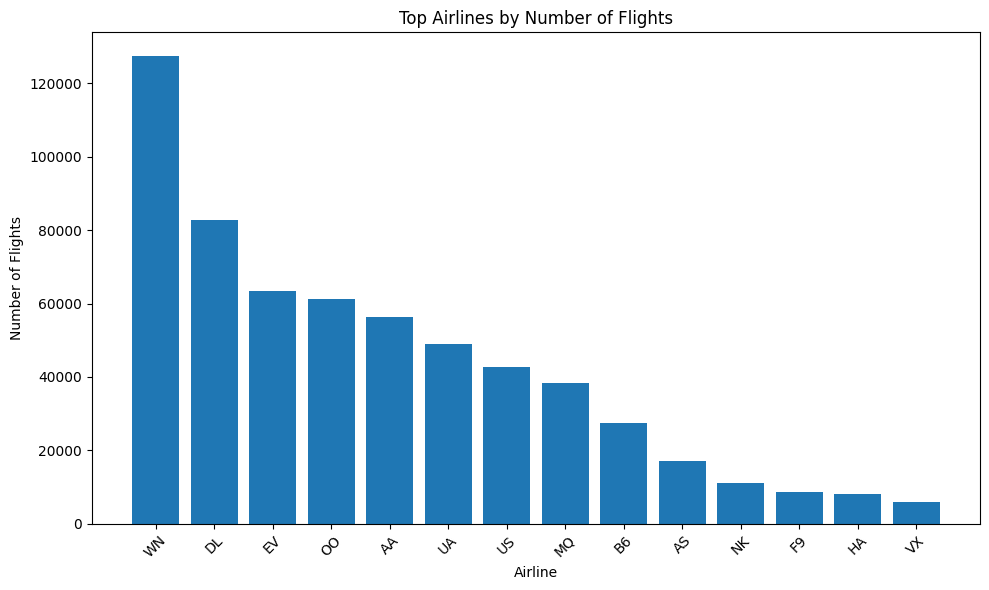

In [23]:
import matplotlib.pyplot as plt

# Top Airlines
top_airlines = df['AIRLINE'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(top_airlines.index, top_airlines.values)

plt.title("Top Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<b> Questions and Answers </b>
1. Why focus on top 15?

Ans: To avoid clutter and highlight major routes.

2. What do we learn?

Ans: Some routes are operated very frequently.

3. Why important?

Ans: High-frequency routes may face congestion.

4. What does it say about demand?

Ans: Demand is strong between major cities.

5. Can this impact delays?

Ans: Yes. Repeated operations increase air traffic density.

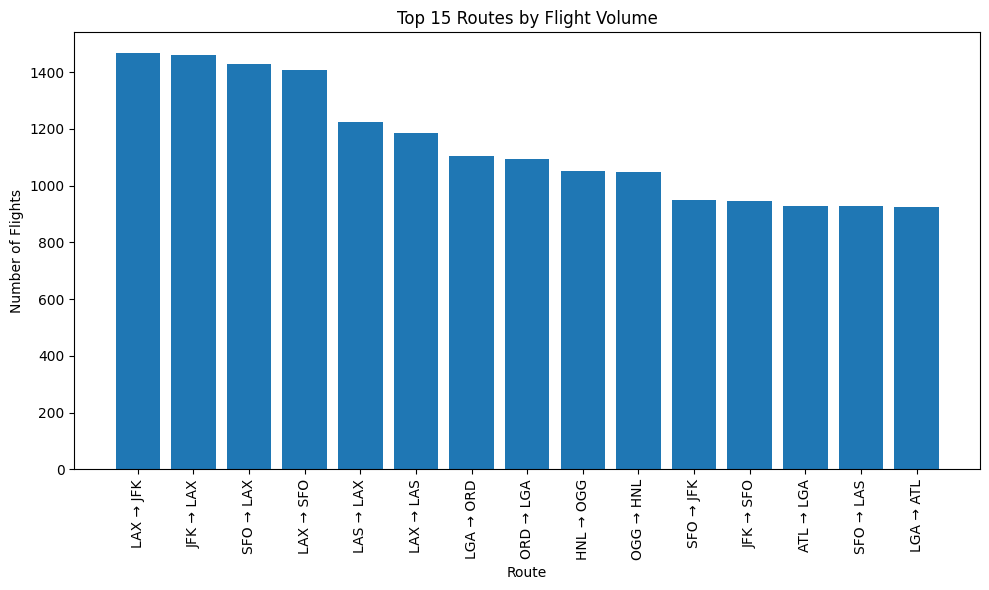

In [24]:
# Top 15 Routes
top_routes = df['ROUTE'].value_counts().head(15)

plt.figure(figsize=(10,6))
plt.bar(top_routes.index, top_routes.values)

plt.title("Top 15 Routes by Flight Volume")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

<b>Questions and Answers</b>
1. Why analyze monthly traffic?

To identify seasonal trends.

2. What pattern is visible?

Some months have higher flights.

3. Why important?

Seasonal demand impacts airport congestion.

4. Can this affect delays?

Yes. Higher flights → higher congestion.

5. What business insight?

Airlines should increase resources during peak months.

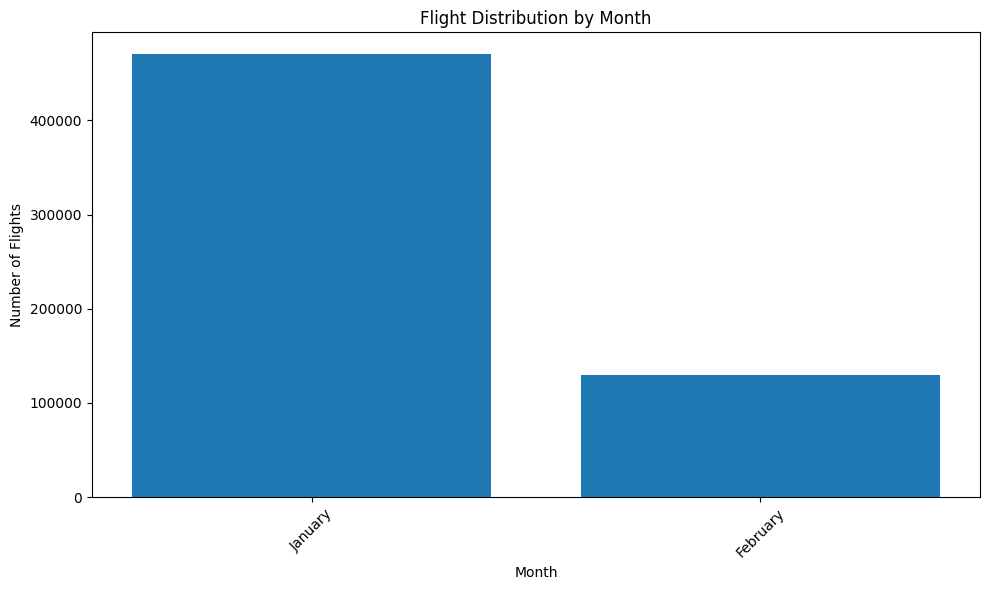

In [25]:
# Busiest Months
monthly_flights = df['MONTH_NAME'].value_counts()

# Maintain proper month order
monthly_flights = monthly_flights.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,6))
plt.bar(monthly_flights.index, monthly_flights.values)

plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<b> Questions and Answers </b>
1. Why not bar chart?

Because days follow order. Line shows trend better.

2. What do we observe?

Weekdays have more flights.

3. Why?

Business travel dominates weekdays.

4. What does this imply?

Air traffic is heavier during workdays.

5. Can this affect delays?

Yes, more weekday congestion.

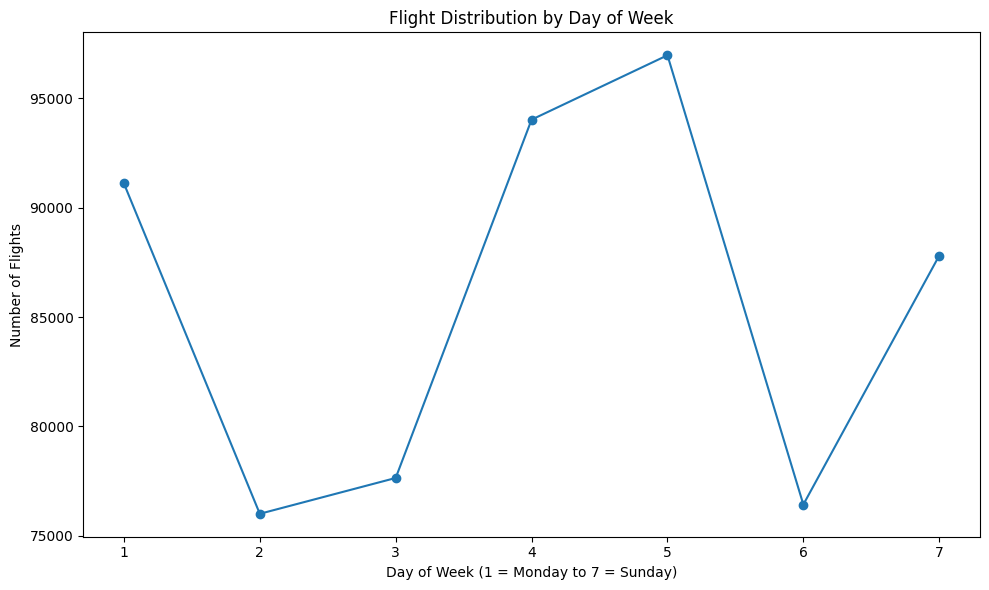

In [26]:
import matplotlib.pyplot as plt

# Flights by Day of Week
day_counts = df['DAY_OF_WEEK'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(day_counts.index, day_counts.values, marker='o')

plt.title("Flight Distribution by Day of Week")
plt.xlabel("Day of Week (1 = Monday to 7 = Sunday)")
plt.ylabel("Number of Flights")

plt.xticks(day_counts.index)
plt.tight_layout()
plt.show()

<b> Why Line Plot?</b>

Because hours are continuous numeric values.

Line plot shows distribution pattern smoothly.

Histogram could also work, but line gives clearer trend.

<b>What do we see?</b>

Most flights fall within specific hour ranges, while very long flights are fewer.

<b>Why it matters?</b>

Understanding travel time helps identify short-haul vs long-haul patterns and operational complexity.

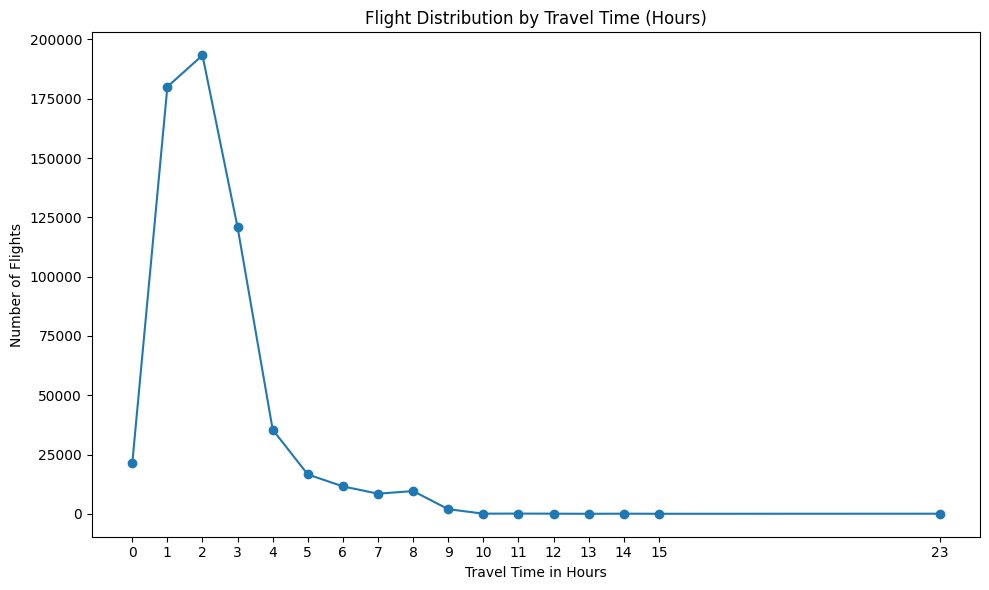

In [27]:
# Create Hour Difference column
df['HOUR_DIFFERENCE'] = (df['ARRIVAL_HOUR'] - df['DEPARTURE_HOUR']) % 24

diff_counts = df['HOUR_DIFFERENCE'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(diff_counts.index, diff_counts.values, marker='o')

plt.title("Flight Distribution by Travel Time (Hours)")
plt.xlabel("Travel Time in Hours")
plt.ylabel("Number of Flights")

plt.xticks(diff_counts.index)
plt.tight_layout()
plt.show()

<b>Questions and Answers </b>
1. Why combine origin and destination?

To measure total airport activity.

2. What do we see?

Traffic concentrated in top hubs.

3. Why important?

Hub congestion increases delays.

4. Business meaning?

Major airports need better management systems.

5. Operational impact?

Higher runway and gate pressure.

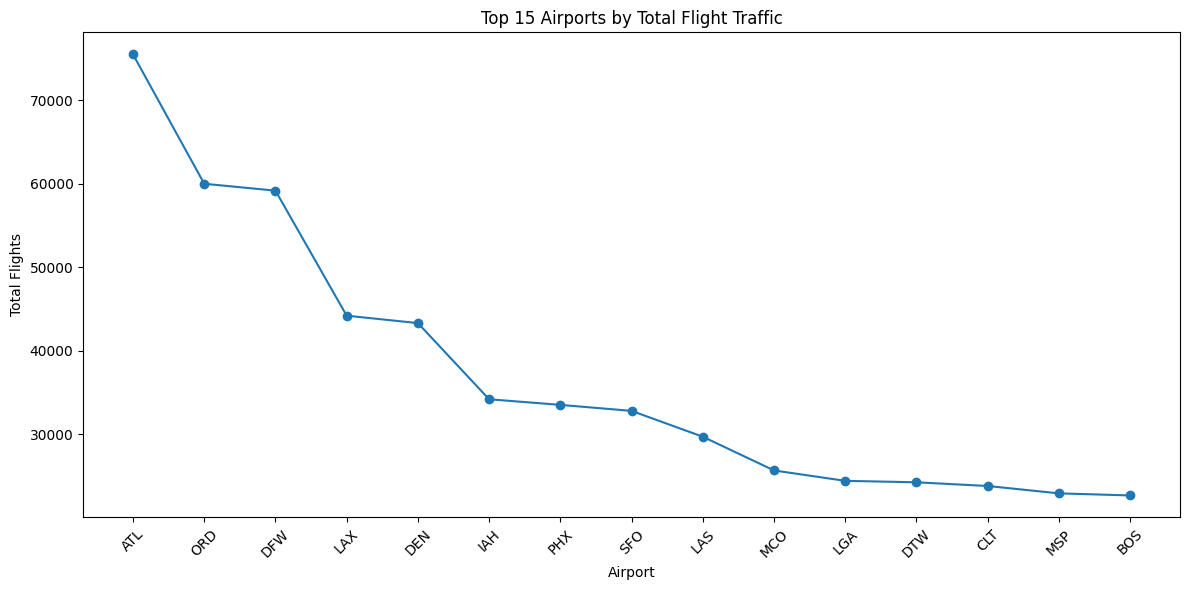

In [28]:
# Flight distribution by airport (Origin + Destination)
origin_counts = df['ORIGIN_AIRPORT'].value_counts()
destination_counts = df['DESTINATION_AIRPORT'].value_counts()

total_airport_traffic = origin_counts.add(destination_counts, fill_value=0)
top_total_airports = total_airport_traffic.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.plot(top_total_airports.index, top_total_airports.values, marker='o')

plt.title("Top 15 Airports by Total Flight Traffic")
plt.xlabel("Airport")
plt.ylabel("Total Flights")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>What Are We Observing?</b>

Most delays are small

Few extreme delays

<b>Questions and Answers </b>
1. Why histogram?

To study delay distribution pattern.

2. What shape is visible?

Right-skewed distribution.

3. What does skew mean?

Few flights have very high delays.

4. Why important?

Outliers impact customer satisfaction.

5. Business insight?

Extreme delays must be reduced.

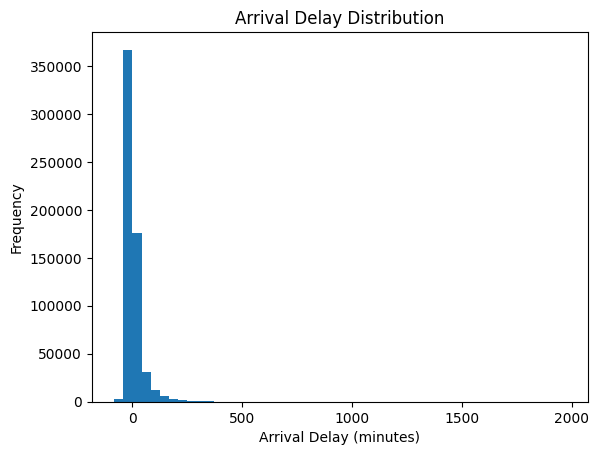

In [29]:
plt.hist(df['ARRIVAL_DELAY'], bins=50)
plt.title("Arrival Delay Distribution")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

<b>Why Boxplot?</b>

Because we compare distribution + spread.

Boxplot shows:

Median delay

Outliers

Variability

Bar chart cannot show spread.

<b>What do we see?</b>

Some airlines have higher median delays and more variability.

<b>Why it matters?</b>

It helps identify delay-prone carriers and operational performance differences.

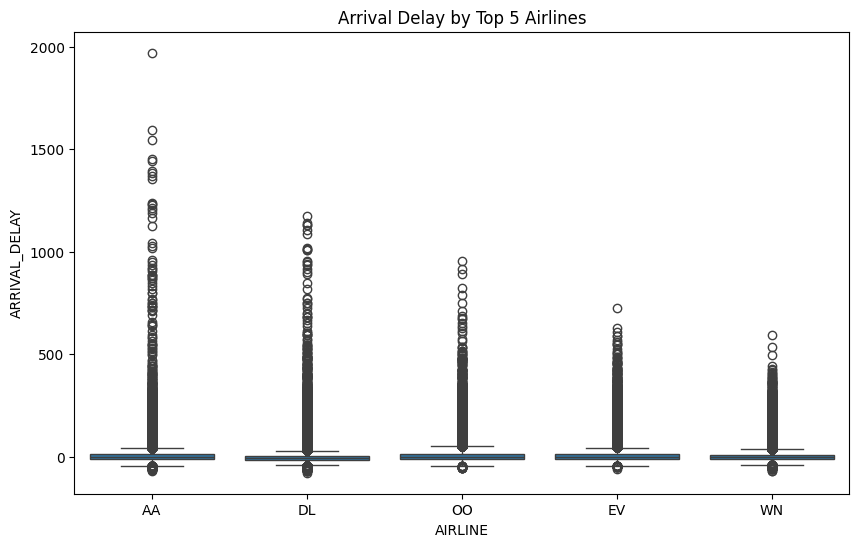

In [30]:
top5_airlines = df['AIRLINE'].value_counts().head(5).index
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['AIRLINE'].isin(top5_airlines)],x='AIRLINE',y='ARRIVAL_DELAY')
plt.title("Arrival Delay by Top 5 Airlines")
plt.show()

<b>What do we see?</b>

Late aircraft delay and airline delay are the major contributors. Weather and security delays are relatively smaller.

<b>Why it matters?</b>

Understanding root causes helps airlines improve scheduling and reduce delays.

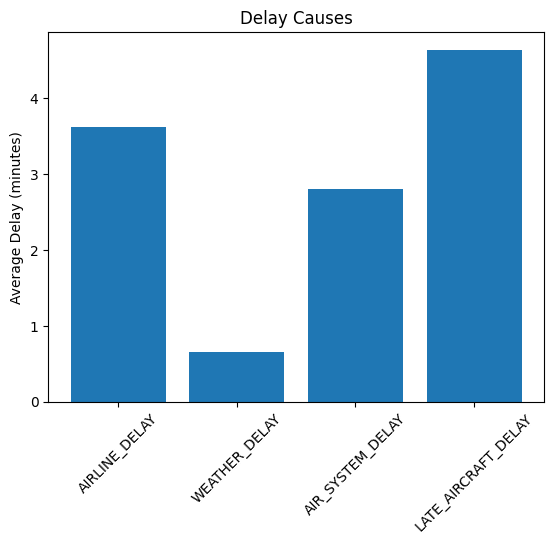

In [31]:
delay_columns = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY'
]
avg_delays = df[delay_columns].mean()
plt.bar(avg_delays.index, avg_delays.values)
plt.title("Delay Causes")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

<b> Questions and Answers </b>
1. Why compare delay types?

To identify root cause.

2. Which delay dominates?

Late aircraft delay.

3. What does it mean?

Previous flight delays affect next flight.

4. Is weather major cause?

No, operational delays dominate.

5. What should airlines improve?

Scheduling efficiency.

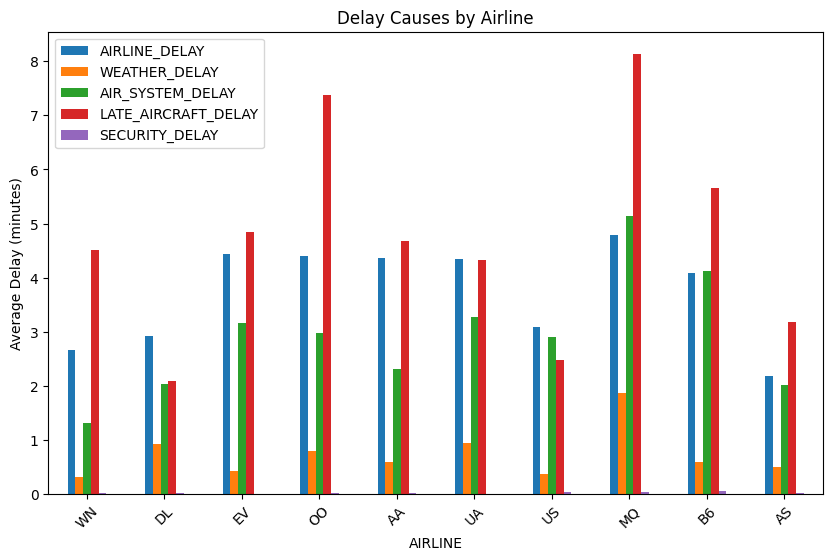

In [32]:
delay_columns = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'SECURITY_DELAY'
]

avg_delay_by_airline = df.groupby('AIRLINE')[delay_columns].mean()

# Show top 10 airlines only for clarity
top_airlines = df['AIRLINE'].value_counts().head(10).index
avg_delay_by_airline = avg_delay_by_airline.loc[top_airlines]
avg_delay_by_airline.plot(kind='bar', figsize=(10,6))
plt.title("Delay Causes by Airline")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

<b> Questions and Answers</b>
1. Why analyze by hour?

To detect peak congestion time.

2. What pattern is visible?

Delays accumulate throughout the day.

3. Why?

Aircraft rotation effect.

4. What business insight?

Morning scheduling is more reliable.

5. Operational recommendation?

Reduce buffer gaps in evening schedules.

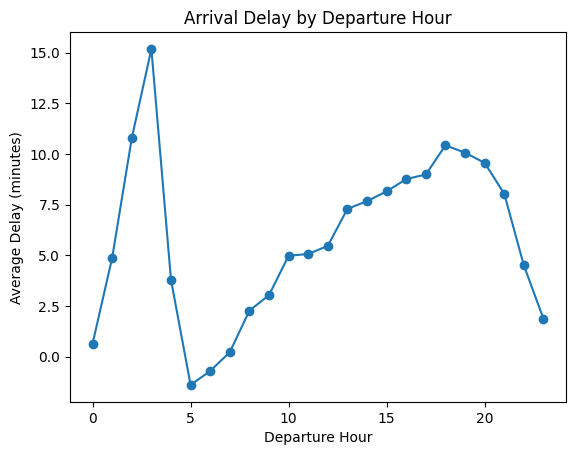

In [33]:
avg_delay_by_hour = df.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean()
plt.plot(avg_delay_by_hour.index,avg_delay_by_hour.values,marker='o')
plt.title("Arrival Delay by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay (minutes)")
plt.show()

# Milestone 3: Route, Cancellation, and Seasonal Insights

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("cleaned_flights.csv")
pd.set_option('display.max_columns', None)
df

C:\Users\my pc\AppData\Local\Temp\ipykernel_21964\3555225780.py:1: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,DEPARTURE_TIME,SCHEDULED_ARRIVAL,ARRIVAL_TIME,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,WEATHER_DELAY,AIRLINE_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED,CANCELLATION_REASON,DIVERTED,AIR_TIME,ELAPSED_TIME,TAXI_IN,TAXI_OUT,DATE,ROUTE,DEPARTURE_HOUR,ARRIVAL_HOUR,MONTH_NAME
0,2015,1,1,4,AS,98,ANC,SEA,1448,5,2354.0,430,408.0,-11.0,-22.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,169.0,194.0,4.0,21.0,2015-01-01,ANC → SEA,0,4,January
1,2015,1,1,4,AA,2336,LAX,PBI,2330,10,2.0,750,741.0,-8.0,-9.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,263.0,279.0,4.0,12.0,2015-01-01,LAX → PBI,0,7,January
2,2015,1,1,4,US,840,SFO,CLT,2296,20,18.0,806,811.0,-2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,266.0,293.0,11.0,16.0,2015-01-01,SFO → CLT,0,8,January
3,2015,1,1,4,AA,258,LAX,MIA,2342,20,15.0,805,756.0,-5.0,-9.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,258.0,281.0,8.0,15.0,2015-01-01,LAX → MIA,0,8,January
4,2015,1,1,4,AS,135,SEA,ANC,1448,25,24.0,320,259.0,-1.0,-21.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,199.0,215.0,5.0,11.0,2015-01-01,SEA → ANC,0,3,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,LAX,BOS,2611,2359,2355.0,819,753.0,-4.0,-26.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,272.0,298.0,4.0,22.0,2015-12-31,LAX → BOS,23,8,December
5819075,2015,12,31,4,B6,745,JFK,PSE,1617,2359,2355.0,446,430.0,-4.0,-16.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,195.0,215.0,3.0,17.0,2015-12-31,JFK → PSE,23,4,December
5819076,2015,12,31,4,B6,1503,JFK,SJU,1598,2359,2350.0,440,432.0,-9.0,-8.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,197.0,222.0,8.0,17.0,2015-12-31,JFK → SJU,23,4,December
5819077,2015,12,31,4,B6,333,MCO,SJU,1189,2359,2353.0,340,330.0,-6.0,-10.0,0.0,0.0,0.0,0.0,0.0,0,Not Cancelled,0,144.0,157.0,3.0,10.0,2015-12-31,MCO → SJU,23,3,December


#### Top 10 Origin–Destination 

Most frequently operated routes

High-demand city pairs

Route-level traffic concentration

<b> What Are We Observing?</b>

Some routes have significantly higher average arrival delays.

Delay is not uniform across all routes.

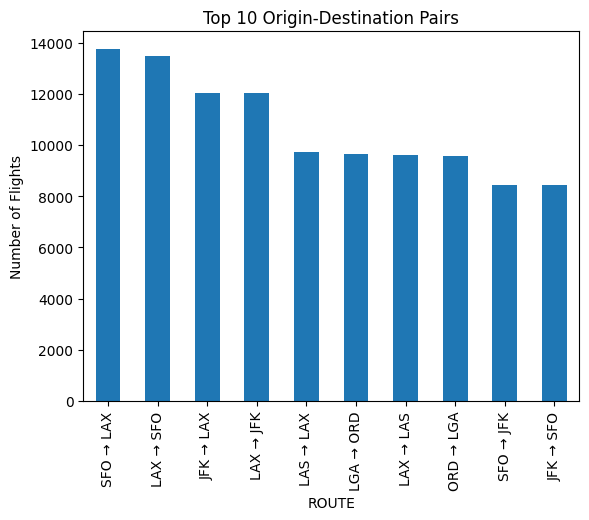

In [36]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure()
top_routes.plot(kind='bar')
plt.title("Top 10 Origin-Destination Pairs")
plt.ylabel("Number of Flights")
plt.xticks(rotation=90)
plt.show()

#### Delay by Route
Most delay-prone routes

Routes affected by congestion or weather

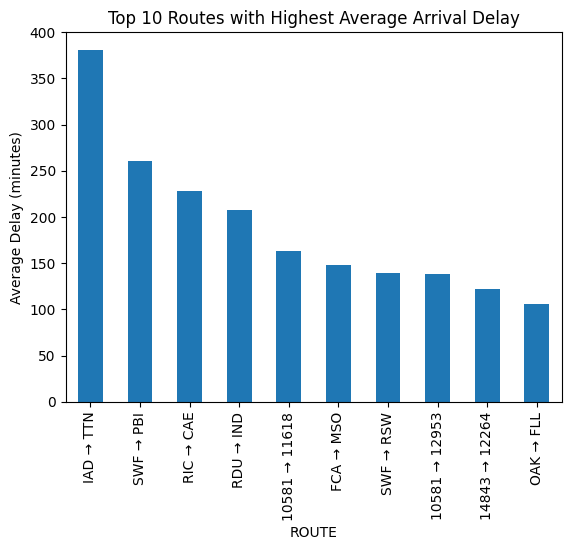

In [37]:
route_delay = df.groupby('ROUTE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure()
route_delay.plot(kind='bar')
plt.title("Top 10 Routes with Highest Average Arrival Delay")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=90)
plt.show()

#### Airport-Level Delay Analysis
Airports with high average delay

Congested or operationally stressed airports

<b>What Are We Observing?</b>

Some airports show higher average arrival delays.

Delay concentration at major hubs.

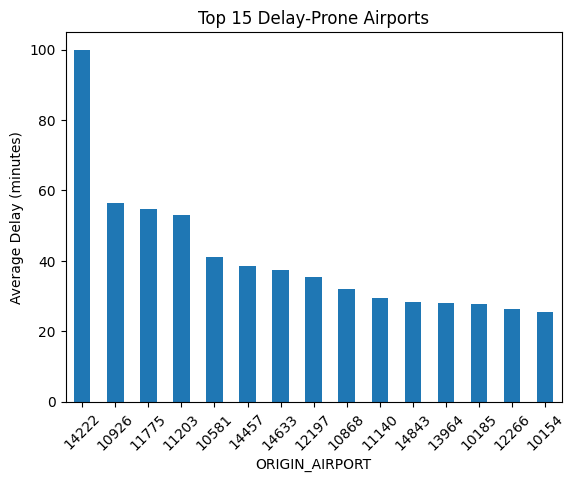

In [38]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean()

top_delay_airports = airport_delay.sort_values(ascending=False).head(15)

plt.figure()
top_delay_airports.plot(kind='bar')
plt.title("Top 15 Delay-Prone Airports")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

#### Heatmap
Which delay type is dominant at each airport

Visual comparison across airports

<b>What Are We Observing?</b>

Different airports have different dominant delay causes.

Some airports show high weather delay.

Others show high airline delay.

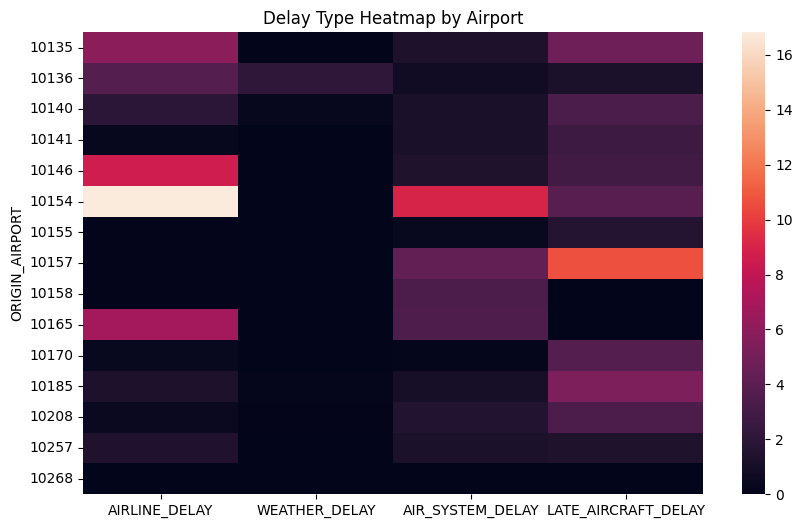

In [39]:
import seaborn as sns

delay_types = ['AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY', 'LATE_AIRCRAFT_DELAY']

airport_delay_types = df.groupby('ORIGIN_AIRPORT')[delay_types].mean().head(15)

plt.figure(figsize=(10,6))
sns.heatmap(airport_delay_types, annot=False)
plt.title("Delay Type Heatmap by Airport")
plt.show()

#### Monthly Cancellation Trend
Which months have more cancellations

Seasonal cancellation pattern

<b>What Are We Observing?</b>

Certain months show higher cancellations.

Seasonal variation is visible.

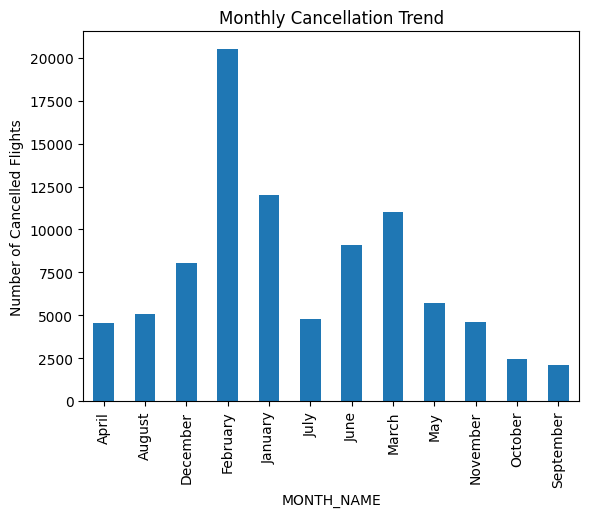

In [40]:
monthly_cancel = df.groupby('MONTH_NAME')['CANCELLED'].sum()

plt.figure()
monthly_cancel.plot(kind='bar')
plt.title("Monthly Cancellation Trend")
plt.ylabel("Number of Cancelled Flights")
plt.xticks(rotation=90)
plt.show()

#### Cancellation Reasons
Column: CANCELLATION_REASON

Codes:
   
    A = Carrier
    
    B = Weather
    
    C = NAS (Air system)
    
    D = Security

Main cause of cancellations

Whether weather or operational issues dominate

<b>What Are We Observing?</b>

Carrier-related cancellations may dominate.

Weather-related cancellations are seasonal.

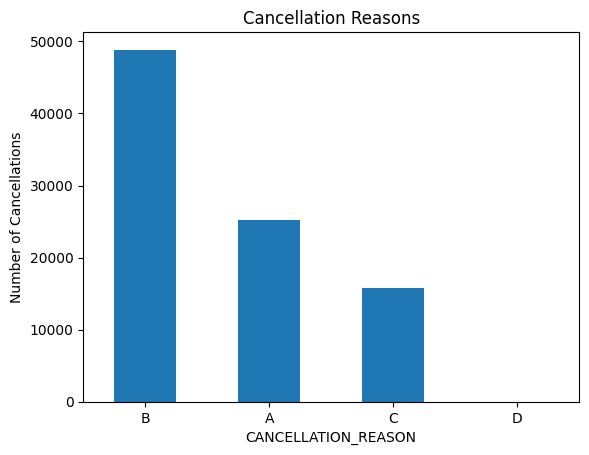

In [41]:
cancel_reason = df[df['CANCELLED'] == 1]['CANCELLATION_REASON'].value_counts()

plt.figure()
cancel_reason.plot(kind='bar')
plt.title("Cancellation Reasons")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=360)
plt.show()

#### Winter Impact Analysis
Whether winter has higher cancellations

<b>What Are We Observing?</b>

Cancellation rates increase in winter.

Weather delay increases during winter months.

In [42]:
winter_months = ['December', 'January', 'February']

winter_data = df[df['MONTH_NAME'].isin(winter_months)]

winter_cancel = winter_data['CANCELLED'].sum()

print("Total Winter Cancellations:", winter_cancel)

Total Winter Cancellations: 40562


#### Delay vs Cancellation Comparison
Whether cancelled flights had higher delay trends

Relationship between severe delay and cancellation

<b>What Are We Observing?</b>

Flights with extreme delays often lead to cancellations.

Operational disruptions escalate.

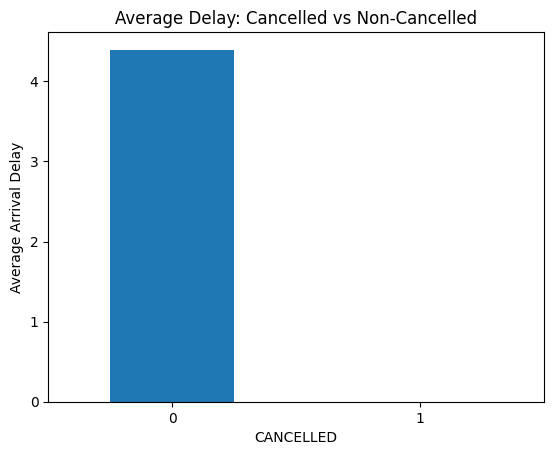

In [43]:
delay_cancel = df.groupby('CANCELLED')['ARRIVAL_DELAY'].mean()

delay_cancel.plot(kind='bar')
plt.title("Average Delay: Cancelled vs Non-Cancelled")
plt.ylabel("Average Arrival Delay")
plt.xticks(rotation=360)
plt.show()

* USA map
* Blue circles on airports
* Bigger circle = more flights
* Click circle → shows number of flights

In [44]:
import folium

In [46]:
# === Busiest Airports Interactive Map ===
busiest = df['ORIGIN_AIRPORT'].value_counts().reset_index()
busiest.columns = ['Airport', 'Flights']

airport_coords = {
    'ATL': [33.6407, -84.4277],
    'ORD': [41.9742, -87.9073],
    'DFW': [32.8998, -97.0403],
    'DEN': [39.8561, -104.6737],
    'LAX': [33.9416, -118.4085],
    'SFO': [37.6213, -122.3790],
    'JFK': [40.6413, -73.7781]
}

map_airports = folium.Map(location=[39.5, -98.35], zoom_start=4)

for i in range(len(busiest.head(10))):
    airport = busiest.loc[i, 'Airport']
    flights = busiest.loc[i, 'Flights']
    
    if airport in airport_coords:
        lat, lon = airport_coords[airport]
        folium.CircleMarker(
            location=[lat, lon],
            radius=flights/5000,
            popup=f"{airport}: {flights} flights",
            color='blue',
            fill=True,
            fill_color='blue'
        ).add_to(map_airports)

# IMPORTANT: Save as HTML file for GitHub
map_airports.save("busiest_airports_map.html")
print("Map saved as busiest_airports_map.html")

map_airports

Map saved as busiest_airports_map.html


# Milestone 4: Report and Presentation

## Milestone 4 – Dashboard and Visualization Summary

In this milestone, interactive dashboards and visualizations were created using Power BI and Python.

The dashboard includes KPI cards, airline analysis, delay analysis, cancellation analysis, and route analysis.

Additionally, a map visualization was created to identify the busiest airports based on flight traffic.

These visualizations help in understanding airline performance and operational efficiency.

## Key Insights

- WN (Southwest Airlines) operates the highest number of flights
- Late aircraft delay is the single largest delay contributor across all airlines
- Evening hours (6–8 PM) show peak delay rates; morning flights are most on-time
- Winter months (Dec–Feb) account for 40,562 cancellations
- Weather is the primary reason for flight cancellations
- SFO → LAX is the busiest domestic route
- Friday is the busiest day of the week for flight operations
- Overall on-time performance: 64.14%